In [ ]:
from google.colab import files
uploaded = files.upload()



Saving AP data.xlsx to AP data (3).xlsx


In [ ]:
!pip install scikit-learn==1.8.0

In [ ]:
import pandas as pd

df = pd.read_excel("AP data.xlsx")
df.head()



,X1,X2,X3,X4,X5,Target,LR,NLR,M5P,RF,...,Unnamed: 50,Unnamed: 51,Unnamed: 52,X1.1,X2.1,X3.1,X4.1,X5.1,Target.1,Unnamed: 59
0,1,9.0,10.0,15.0,60.0,2405,3341.501289,2543.920652,3340.594,2631.286,...,NaN,NaN,Minimum,1,9,5,15,60,450,Training
1,1,9.0,15.0,15.0,60.0,3201,3521.428984,2958.436570,3489.224,3157.045,...,NaN,NaN,NaN,1,9,5,15,60,490,Testing
2,1,9.0,20.0,15.0,60.0,3260,3701.356678,3292.887557,3637.854,3267.629,...,NaN,NaN,Mean,1.241667,13.425,59.25,29.75,74.5,4458.65,Training
3,1,9.0,25.0,15.0,60.0,3302,3881.284372,3578.132823,3786.484,3346.119,...,NaN,NaN,NaN,1.267857,13.660714,53.75,30.535714,76.071429,4256.125,Testing
4,1,9.0,30.0,15.0,60.0,3422,4061.212067,3829.442935,3935.114,3475.343,...,NaN,NaN,Maximum,2,18,110,45,120,10159,Training


DATA CLEANING

In [ ]:
df.shape



(158, 60)

In [ ]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'Target', 'LR', 'NLR', 'M5P', 'RF', 'RT',
       'REP Tree', 'GP_PUK', 'GP_RBF', 'Unnamed: 14', 'LR.1', 'NLR.1', 'M5P.1',
       'RF.1', 'RT.1', 'REP Tree.1', 'GP_PUK.1', 'GP_RBF.1', 'Unnamed: 23',
       'LR.2', 'NLR.2', 'M5P.2', 'RF.2', 'RT.2', 'REP Tree.2', 'GP_PUK.2',
       'GP_RBF.2', 'Unnamed: 32', 'Unnamed: 33', 'LR.3', 'NLR.3', 'M5P.3',
       'RF.3', 'RT.3', 'REP Tree.3', 'GP_PUK.3', 'GP_RBF.3', 'Unnamed: 42',
       'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46',
       'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50',
       'Unnamed: 51', 'Unnamed: 52', 'X1.1', 'X2.1', 'X3.1', 'X4.1', 'X5.1',
       'Target.1', 'Unnamed: 59'],
      dtype='object')

In [ ]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,X1,X2,X3,X4,X5,Target,LR,NLR,M5P,RF,...,RT.3,REP Tree.3,GP_PUK.3,GP_RBF.3,X1.1,X2.1,X3.1,X4.1,X5.1,Target.1
0,1,9.0,10.0,15.0,60.0,2405,3341.501289,2543.920652,3340.594,2631.286,...,1.686991e+07,11521272.49,1.484599e+07,1.592820e+07,1,9,5,15,60,450
1,1,9.0,15.0,15.0,60.0,3201,3521.428984,2958.436570,3489.224,3157.045,...,5.856642e+06,6751162.89,8.066600e+06,8.051236e+06,1,9,5,15,60,490
2,1,9.0,20.0,15.0,60.0,3260,3701.356678,3292.887557,3637.854,3267.629,...,5.574557e+06,6448044.49,6.403122e+06,5.885491e+06,1.241667,13.425,59.25,29.75,74.5,4458.65
3,1,9.0,25.0,15.0,60.0,3302,3881.284372,3578.132823,3786.484,3346.119,...,5.377993e+06,6236507.29,4.830435e+06,4.169384e+06,1.267857,13.660714,53.75,30.535714,76.071429,4256.125
4,1,9.0,30.0,15.0,60.0,3422,4061.212067,3829.442935,3935.114,3475.343,...,4.835821e+06,5651555.29,3.043549e+06,2.544137e+06,2,18,110,45,120,10159


In [ ]:
df.shape


(158, 44)

In [ ]:
df.tail(10)


,X1,X2,X3,X4,X5,Target,LR,NLR,M5P,RF,...,RT.3,REP Tree.3,GP_PUK.3,GP_RBF.3,X1.1,X2.1,X3.1,X4.1,X5.1,Target.1
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.dropna(how='all')
df.shape


(156, 44)

In [ ]:
df = df[['X1','X2','X3','X4','X5','Target']]
df.shape


(156, 6)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 0 to 157
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      127 non-null    object 
 1   X2      127 non-null    float64
 2   X3      127 non-null    float64
 3   X4      127 non-null    float64
 4   X5      127 non-null    float64
 5   Target  135 non-null    object 
dtypes: float64(4), object(2)
memory usage: 8.5+ KB


In [ ]:
df.isnull().sum()


,0
X1,29
X2,29
X3,29
X4,29
X5,29
Target,21


In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')


In [ ]:
df = df.dropna()
df.shape


(120, 6)

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      120 non-null    float64
 1   X2      120 non-null    float64
 2   X3      120 non-null    float64
 3   X4      120 non-null    float64
 4   X5      120 non-null    float64
 5   Target  120 non-null    float64
dtypes: float64(6)
memory usage: 6.6 KB


,0
X1,0
X2,0
X3,0
X4,0
X5,0
Target,0


In [ ]:
print(df.head(40))

     X1    X2     X3    X4    X5  Target
0   1.0   9.0   10.0  15.0  60.0  2405.0
1   1.0   9.0   15.0  15.0  60.0  3201.0
2   1.0   9.0   20.0  15.0  60.0  3260.0
3   1.0   9.0   25.0  15.0  60.0  3302.0
4   1.0   9.0   30.0  15.0  60.0  3422.0
5   1.0   9.0   40.0  15.0  60.0  4825.0
6   1.0   9.0   45.0  15.0  60.0  4865.0
7   1.0   9.0   50.0  15.0  60.0  4884.0
8   1.0   9.0   55.0  15.0  60.0  5510.0
9   1.0   9.0   70.0  15.0  60.0  5642.0
10  1.0   9.0   75.0  15.0  60.0  5675.0
11  1.0   9.0   80.0  15.0  60.0  5685.0
12  1.0   9.0   85.0  15.0  60.0  5698.0
13  1.0   9.0   90.0  15.0  60.0  5758.0
14  1.0   9.0  105.0  15.0  60.0  5852.0
15  1.0   9.0  110.0  15.0  60.0  5859.0
16  1.0   9.0   10.0  45.0  60.0   944.0
17  1.0   9.0   15.0  45.0  60.0   975.0
18  1.0   9.0   20.0  45.0  60.0   987.0
19  1.0   9.0   30.0  45.0  60.0  1075.0
20  1.0   9.0   35.0  45.0  60.0  1220.0
21  1.0   9.0   50.0  45.0  60.0  2140.0
22  1.0   9.0   55.0  45.0  60.0  2156.0
23  1.0   9.0   

Feature & Target Separation

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]
print(X)
print(y)

      X1   X2     X3    X4    X5
0    1.0  9.0   10.0  15.0  60.0
1    1.0  9.0   15.0  15.0  60.0
2    1.0  9.0   20.0  15.0  60.0
3    1.0  9.0   25.0  15.0  60.0
4    1.0  9.0   30.0  15.0  60.0
..   ...  ...    ...   ...   ...
115  2.0  9.0   80.0  45.0  60.0
116  2.0  9.0   90.0  45.0  60.0
117  2.0  9.0   95.0  45.0  60.0
118  2.0  9.0  100.0  45.0  60.0
119  2.0  9.0  110.0  45.0  60.0

[120 rows x 5 columns]
0      2405.0
1      3201.0
2      3260.0
3      3302.0
4      3422.0
        ...  
115     710.0
116     756.0
117     776.0
118     778.0
119     783.0
Name: Target, Length: 120, dtype: float64


Train Test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape)
print(X_test.shape)


(96, 5)
(24, 5)


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import explained_variance_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

cc = np.corrcoef(y_test, y_pred_lr)[0,1]
y_pred_lr = np.clip(y_pred_lr, 0, None)

print("Linear Regression Results:")
print("R2:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_lr))
print("Explained Variance:", explained_variance_score(y_test, y_pred_lr))
print("CC:", cc)

Linear Regression Results:
R2: 0.8756218024852737
RMSE: 1103.8326749233406
MAE: 827.3160896036987
MAPE: 0.28468602859615505
Explained Variance: 0.8775009066588608
CC: 0.9442064509589041


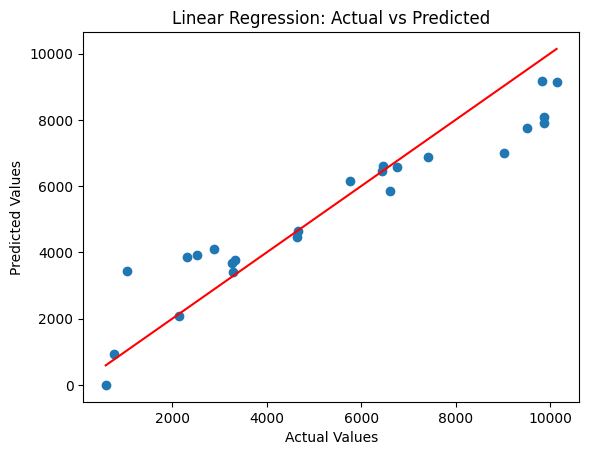

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


LASSO REGRESSION

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, explained_variance_score
import numpy as np
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
cc = np.corrcoef(y_test, y_pred_lasso)[0,1]
y_pred_lasso = np.clip(y_pred_lasso, 0, None)


print("Lasso Regression Results:")
print("R2:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_lasso))
print("Explained Variance:", explained_variance_score(y_test, y_pred_lasso))
print("CC:", cc)

Lasso Regression Results:
R2: 0.875621141192825
RMSE: 1103.8356093413372
MAE: 827.3160218201698
MAPE: 0.284686184727125
Explained Variance: 0.8775002496533393
CC: 0.9442068814994384


RIDGE REGRESSION


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, explained_variance_score
import numpy as np
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

cc = np.corrcoef(y_test, y_pred_ridge)[0,1]
y_pred_ridge = np.clip(y_pred_ridge, 0, None)
print("Ridge Regression Results:")
print("R2:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_ridge))
print("Explained Variance:", explained_variance_score(y_test, y_pred_ridge))
print("CC:", cc)

Ridge Regression Results:
R2: 0.8732138232581421
RMSE: 1114.4666301012608
MAE: 835.8959931948939
MAPE: 0.28695354670572054
Explained Variance: 0.8752659966417803
CC: 0.944324739011462


Elastic Net Regression

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, explained_variance_score
import numpy as np

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
y_pred_elastic = elastic.predict(X_test_scaled)
cc = np.corrcoef(y_test, y_pred_elastic)[0,1]
y_pred_elastic = np.clip(y_pred_elastic, 0, None)
print("Elastic Net Results:")
print("R2:", r2_score(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_elastic))
print("Explained Variance:", explained_variance_score(y_test, y_pred_elastic))
print("CC:", cc)

Elastic Net Results:
R2: 0.8744740793242699
RMSE: 1108.9138914593418
MAE: 831.1056234158099
MAPE: 0.2857240935226943
Explained Variance: 0.876435386703708
CC: 0.944266745917058


Support Vector Regression (SVR)

In [ ]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test)

print("SVR Results:")
print("R2:", r2_score(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))


SVR Results:
R2: -0.491528301393386
RMSE: 3822.494467015301
MAE: 3032.8739088475704


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

best_svr = grid.best_estimator_

y_pred_svr = best_svr.predict(X_test_scaled)

cc = np.corrcoef(y_test, y_pred_svr)[0,1]

print("SVR Results:")
print("R2:", r2_score(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_svr))
print("Explained Variance:", explained_variance_score(y_test, y_pred_svr))
print("CC:", cc)

Best Parameters: {'C': 1000, 'epsilon': 1, 'gamma': 'scale'}
SVR Results:
R2: 0.9691122533641683
RMSE: 550.0779409494681
MAE: 341.7360395594922
MAPE: 0.08439217852971126
Explained Variance: 0.9731945602978376
CC: 0.9897620253008779


ANN (Neural Network)

In [ ]:
import tensorflow as tf
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, explained_variance_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping



# Build ANN Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile Model

model.compile(
    optimizer='adam',
    loss='mse'
)

# Early stopping (prevents overfitting)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Train Model

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_ann = model.predict(X_test_scaled).flatten()

# remove negative predictions (optional for physical quantities)
y_pred_ann = np.clip(y_pred_ann, 0, None)

# Evaluation Metrics
cc = np.corrcoef(y_test, y_pred_ann)[0,1]

print("ANN Results:")
print("R2:", r2_score(y_test, y_pred_ann))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ann)))
print("MAE:", mean_absolute_error(y_test, y_pred_ann))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_ann))
print("Explained Variance:", explained_variance_score(y_test, y_pred_ann))
print("CC:", cc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
ANN Results:
R2: 0.9265879366234515
RMSE: 848.037059878471
MAE: 704.3944962819418
MAPE: 0.22652467606943327
Explained Variance: 0.9330409965383194
CC: 0.9660358467011371


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR (Tuned)", "ANN"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_ann)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ann))
    ]
})

results


,Model,R2,RMSE
0,Linear Regression,0.875622,1103.832675
1,SVR (Tuned),0.969112,550.077941
2,ANN,0.926588,848.037060


Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

cc = np.corrcoef(y_test, y_pred_dt)[0,1]

print("Decision Tree Results:")
print("R2:", r2_score(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_dt))
print("Explained Variance:", explained_variance_score(y_test, y_pred_dt))
print("CC:", cc)

Decision Tree Results:
R2: 0.9837405136816442
RMSE: 399.1025721132991
MAE: 274.11377314814814
MAPE: 0.07289646107404969
Explained Variance: 0.9837889995898973
CC: 0.9920492548585336


In [ ]:
!pip install xgboost


In [ ]:
print(X.describe())

               X1         X2          X3          X4          X5
count  120.000000  120.00000  120.000000  120.000000  120.000000
mean     1.241667   13.42500   59.250000   29.750000   74.500000
std      0.429888    4.51824   31.996914   15.060801   25.793296
min      1.000000    9.00000    5.000000   15.000000   60.000000
25%      1.000000    9.00000   35.000000   15.000000   60.000000
50%      1.000000    9.00000   55.000000   15.000000   60.000000
75%      1.000000   18.00000   85.000000   45.000000   60.000000
max      2.000000   18.00000  110.000000   45.000000  120.000000


In [ ]:
X = X.copy()

# Fix skewness
X.loc[:, 'X2'] = np.log1p(X['X2'])
X.loc[:, 'X3'] = np.log1p(X['X3'])
X.loc[:, 'X4'] = np.log1p(X['X4'])
X.loc[:, 'X5'] = np.log1p(X['X5'])

XG Boost Regressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    reg_alpha=0,
    reg_lambda=1,
    subsample=1,
    colsample_bytree=1,
    random_state=42

)

xgb.fit(X_train, y_train)


y_pred_xgb = xgb.predict(X_test)

cc = np.corrcoef(y_test, y_pred_xgb)[0,1]

print("XGBoost Results:")
print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_xgb))
print("Explained Variance:", explained_variance_score(y_test, y_pred_xgb))
print("CC:", cc)

XGBoost Results:
R2: 0.9959887994945991
RMSE: 198.22950747511743
MAE: 131.2446034749349
MAPE: 0.06101817621318356
Explained Variance: 0.9959934065697881
CC: 0.9981107489265052


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR (Tuned)", "ANN", "XGBoost"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_ann),
        r2_score(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ann)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

results


,Model,R2,RMSE
0,Linear Regression,0.875622,1103.832675
1,SVR (Tuned),0.969112,550.077941
2,ANN,0.926588,848.037060
3,XGBoost,0.995989,198.229507


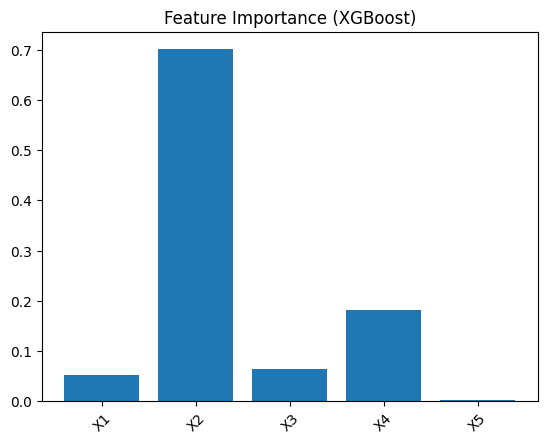

In [ ]:
plt.bar(X.columns, xgb.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.xticks(rotation=45)
plt.show()


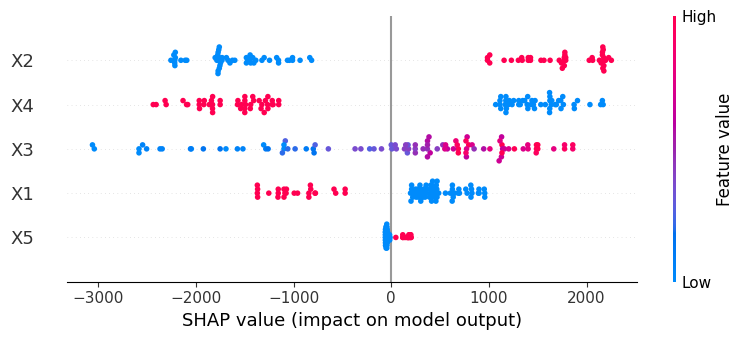

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

RESULT


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Decision Tree",
        "SVR (Tuned)",
        "ANN",
        "XGBoost"
    ],

    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_ann),
        r2_score(y_test, y_pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ann)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

results

,Model,R2,RMSE
0,Linear Regression,0.875622,1103.832675
1,Ridge,0.873214,1114.466630
2,Decision Tree,0.983741,399.102572
3,SVR (Tuned),0.969112,550.077941
4,ANN,0.926588,848.037060
5,XGBoost,0.995989,198.229507


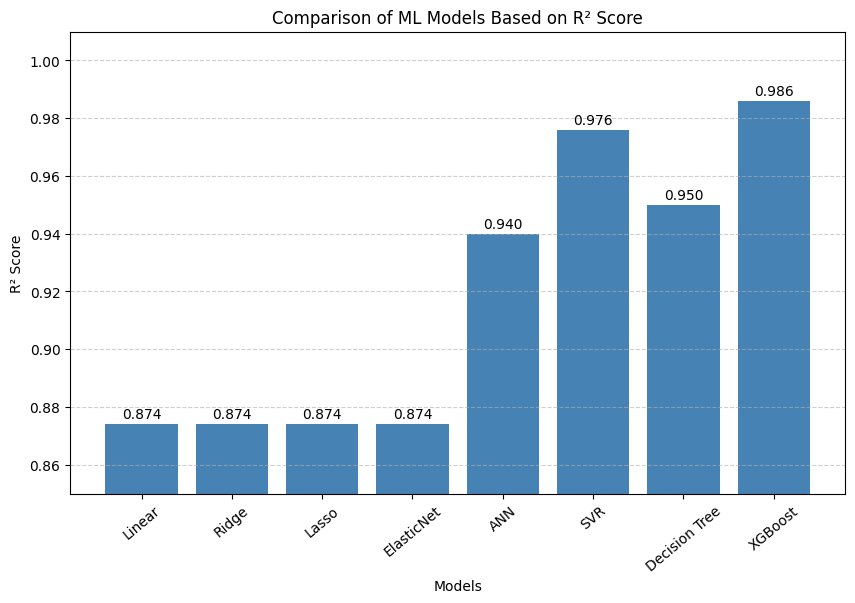

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Linear",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "ANN",
    "SVR",
    "Decision Tree",
    "XGBoost"
]

# R2 scores (replace Decision Tree with your actual value)
r2_scores = [
    0.874,
    0.874,
    0.874,
    0.874,
    0.940,
    0.976,
    0.95,   # replace with your Decision Tree
    0.986
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, r2_scores, color="steelblue")

plt.ylabel("R² Score")
plt.xlabel("Models")
plt.title("Comparison of ML Models Based on R² Score")

plt.xticks(rotation=40)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.002,
             f"{height:.3f}",
             ha='center')

plt.ylim(0.85,1.01)

plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.show()

MATPLOTLIB GRAPHS


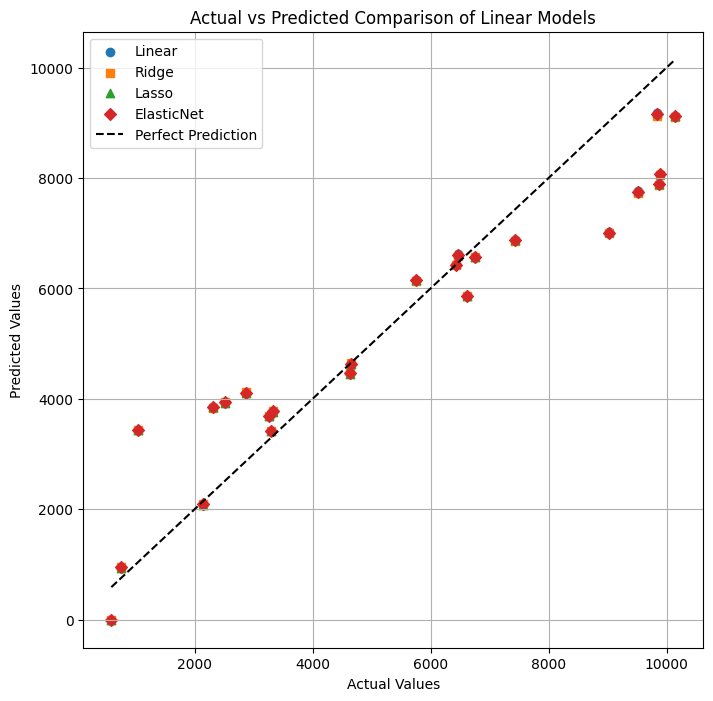

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Scatter plots for each model
plt.scatter(y_test, y_pred_lr, label="Linear", marker='o')
plt.scatter(y_test, y_pred_ridge, label="Ridge", marker='s')
plt.scatter(y_test, y_pred_lasso, label="Lasso", marker='^')
plt.scatter(y_test, y_pred_elastic, label="ElasticNet", marker='D')

# Ideal line
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='black',
         linestyle='--',
         label="Perfect Prediction")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Comparison of Linear Models")

plt.legend()
plt.grid(True)

plt.show()

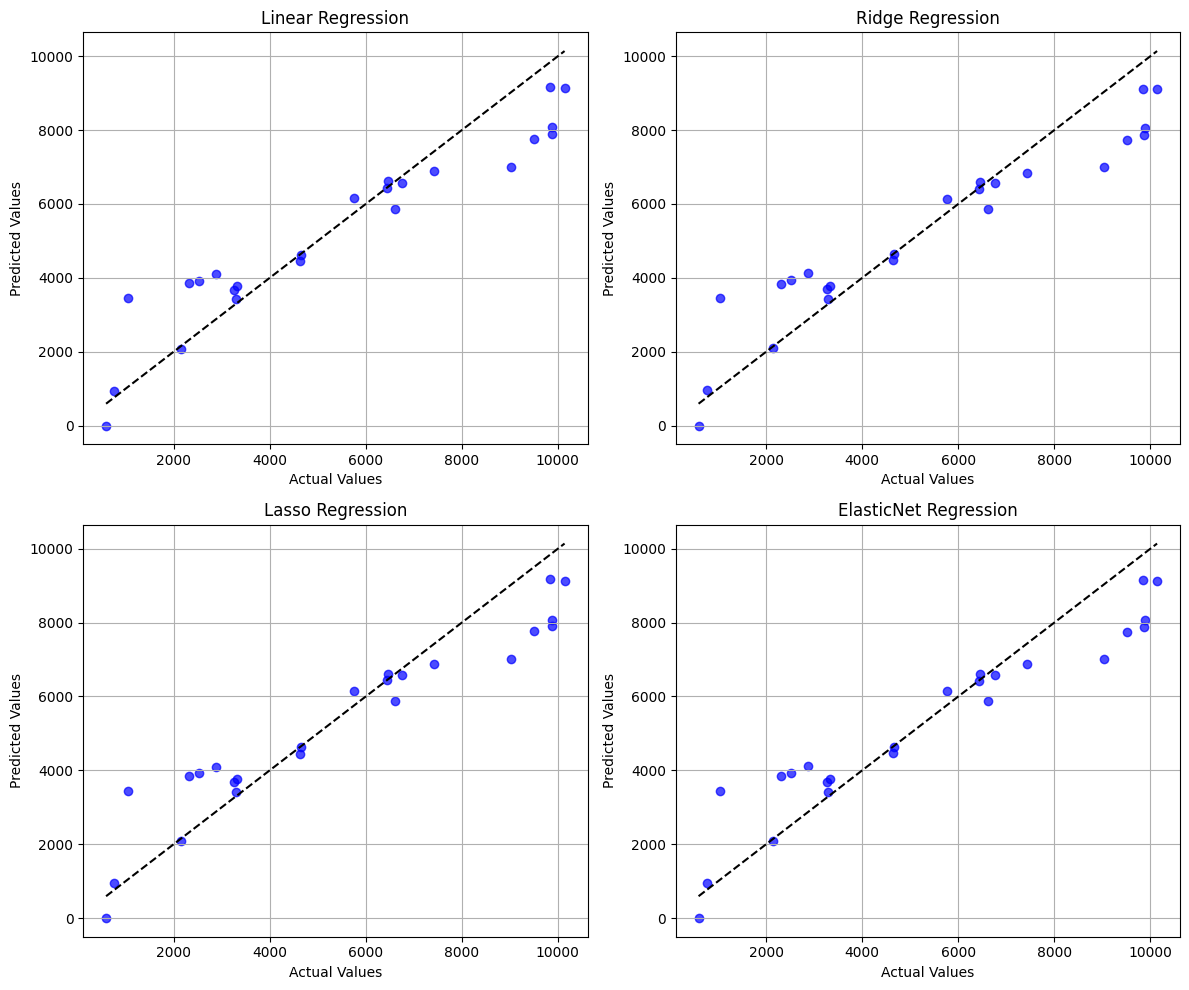

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Remove negative predictions
y_pred_lr = np.clip(y_pred_lr, 0, None)
y_pred_ridge = np.clip(y_pred_ridge, 0, None)
y_pred_lasso = np.clip(y_pred_lasso, 0, None)
y_pred_elastic = np.clip(y_pred_elastic, 0, None)

# Create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12,10))

models = [
    ("Linear Regression", y_pred_lr),
    ("Ridge Regression", y_pred_ridge),
    ("Lasso Regression", y_pred_lasso),
    ("ElasticNet Regression", y_pred_elastic)
]

for ax, (title, preds) in zip(axes.flatten(), models):

    ax.scatter(y_test, preds, color="blue", alpha=0.7)

    # perfect prediction line
    min_val = min(y_test)
    max_val = max(y_test)

    ax.plot([min_val, max_val],
            [min_val, max_val],
            'k--')

    ax.set_title(title)
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)

plt.tight_layout()
plt.show()

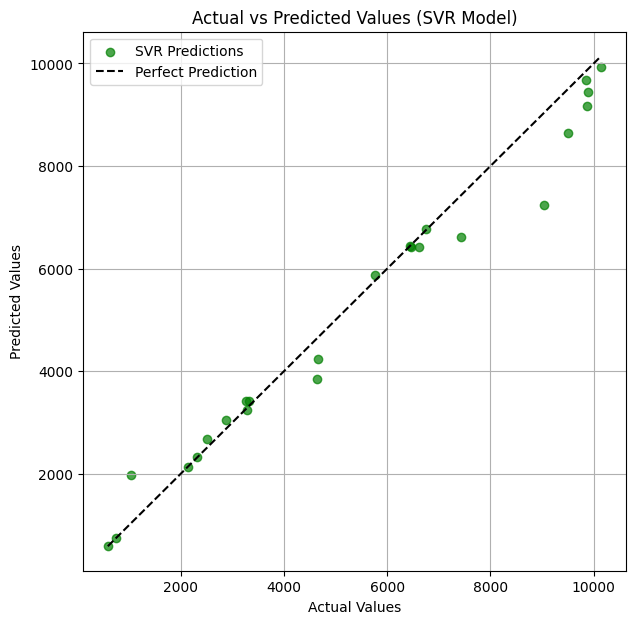

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Remove negative predictions (optional but safer)
y_pred_svr = np.clip(y_pred_svr, 0, None)

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_svr,
            color="green",
            alpha=0.7,
            label="SVR Predictions")

# Perfect prediction line
min_val = min(y_test)
max_val = max(y_test)

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k--',
         label="Perfect Prediction")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (SVR Model)")

plt.legend()
plt.grid(True)

plt.show()

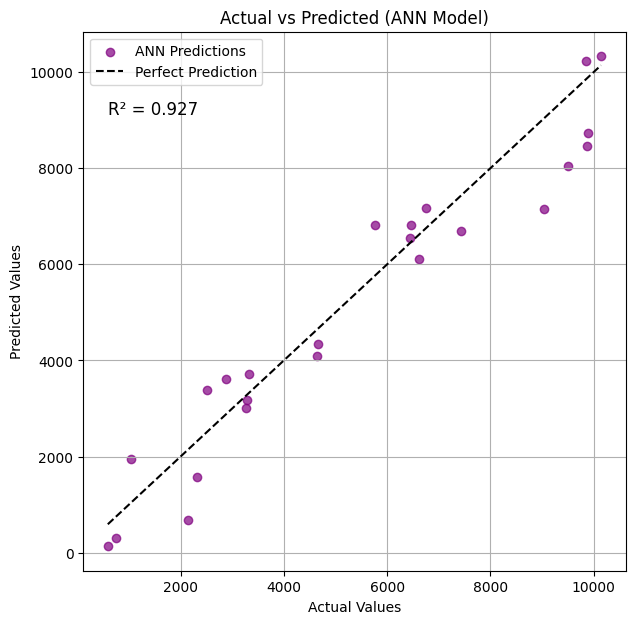

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Ensure predictions are 1D
y_pred_ann = y_pred_ann.flatten()

# Remove negative predictions (optional for physical values)
y_pred_ann = np.clip(y_pred_ann, 0, None)

plt.figure(figsize=(7,7))

# Scatter plot
plt.scatter(y_test, y_pred_ann,
            color='purple',
            alpha=0.7,
            label="ANN Predictions")

# Perfect prediction line
min_val = min(y_test)
max_val = max(y_test)

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k--',
         label="Perfect Prediction")

# Calculate R2
r2 = r2_score(y_test, y_pred_ann)

plt.text(min_val, max_val*0.9,
         f"R² = {r2:.3f}",
         fontsize=12)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (ANN Model)")

plt.legend()
plt.grid(True)


plt.show()

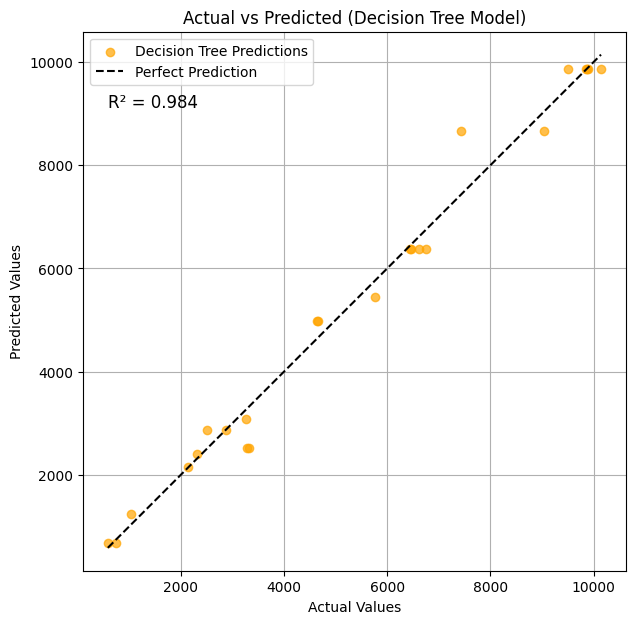

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Optional: remove negative predictions
y_pred_dt = np.clip(y_pred_dt, 0, None)

plt.figure(figsize=(7,7))

# Scatter plot
plt.scatter(y_test, y_pred_dt,
            color="orange",
            alpha=0.7,
            label="Decision Tree Predictions")

# Perfect prediction line
min_val = min(y_test)
max_val = max(y_test)

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k--',
         label="Perfect Prediction")

# Calculate R2
r2 = r2_score(y_test, y_pred_dt)

plt.text(min_val, max_val*0.9,
         f"R² = {r2:.3f}",
         fontsize=12)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Decision Tree Model)")

plt.legend()
plt.grid(True)

plt.axis('equal')

plt.show()

In [ ]:
from sklearn.metrics import r2_score

y_pred = xgb.predict(X_test)
print("R2:", r2_score(y_test, y_pred))

R2: 0.9959887994945991


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


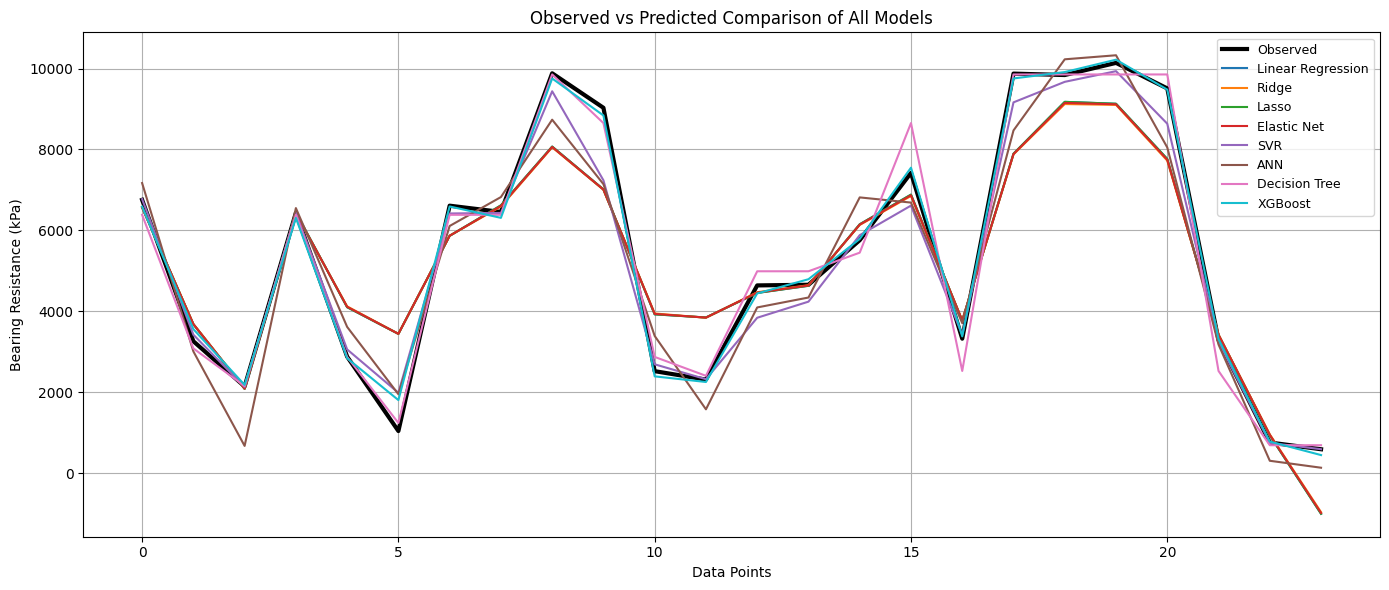

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Observed values ---
y_true = y_test.values

# --- Predictions (IMPORTANT: use correct inputs) ---
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_elastic = elastic.predict(X_test_scaled)
y_pred_svr = best_svr.predict(X_test_scaled)
y_pred_ann = model.predict(X_test_scaled).flatten()   # ANN
y_pred_dt = dt.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# --- Plot ---
plt.figure(figsize=(14,6))

plt.plot(y_true, label="Observed", color="black", linewidth=3)

plt.plot(y_pred_lr, label="Linear Regression", color="#1f77b4")
plt.plot(y_pred_ridge, label="Ridge", color="#ff7f0e")
plt.plot(y_pred_lasso, label="Lasso", color="#2ca02c")
plt.plot(y_pred_elastic, label="Elastic Net", color="#d62728")
plt.plot(y_pred_svr, label="SVR", color="#9467bd")
plt.plot(y_pred_ann, label="ANN", color="#8c564b")
plt.plot(y_pred_dt, label="Decision Tree", color="#e377c2")
plt.plot(y_pred_xgb, label="XGBoost", color="#17becf")

# Labels
plt.xlabel("Data Points")
plt.ylabel("Bearing Resistance (kPa)")
plt.title("Observed vs Predicted Comparison of All Models")

# Styling
plt.legend(loc='upper right', fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 


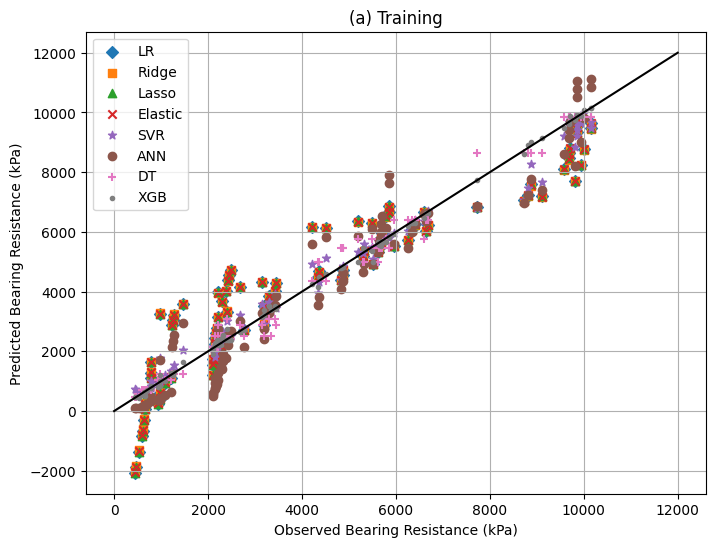

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Predictions (training)
plt.scatter(y_train, lr.predict(X_train_scaled), label="LR", marker='D')
plt.scatter(y_train, ridge.predict(X_train_scaled), label="Ridge", marker='s')
plt.scatter(y_train, lasso.predict(X_train_scaled), label="Lasso", marker='^')
plt.scatter(y_train, elastic.predict(X_train_scaled), label="Elastic", marker='x')
plt.scatter(y_train, best_svr.predict(X_train_scaled), label="SVR", marker='*')
plt.scatter(y_train, model.predict(X_train_scaled).flatten(), label="ANN", marker='o')
plt.scatter(y_train, dt.predict(X_train), label="DT", marker='+')
plt.scatter(y_train, xgb.predict(X_train), label="XGB", marker='.')

# Perfect line
plt.plot([0,12000],[0,12000],'k-')

plt.xlabel("Observed Bearing Resistance (kPa)")
plt.ylabel("Predicted Bearing Resistance (kPa)")
plt.title("(a) Training")

plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


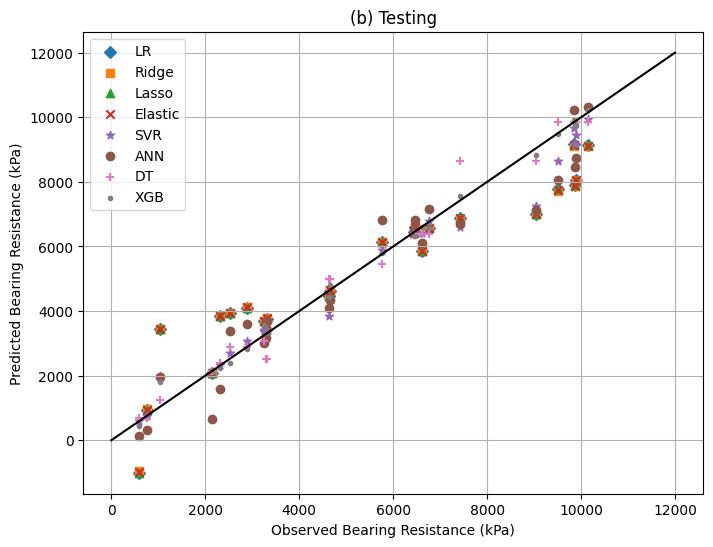

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr.predict(X_test_scaled), label="LR", marker='D')
plt.scatter(y_test, ridge.predict(X_test_scaled), label="Ridge", marker='s')
plt.scatter(y_test, lasso.predict(X_test_scaled), label="Lasso", marker='^')
plt.scatter(y_test, elastic.predict(X_test_scaled), label="Elastic", marker='x')
plt.scatter(y_test, best_svr.predict(X_test_scaled), label="SVR", marker='*')
plt.scatter(y_test, model.predict(X_test_scaled).flatten(), label="ANN", marker='o')
plt.scatter(y_test, dt.predict(X_test), label="DT", marker='+')
plt.scatter(y_test, xgb.predict(X_test), label="XGB", marker='.')

plt.plot([0,12000],[0,12000],'k-')

plt.xlabel("Observed Bearing Resistance (kPa)")
plt.ylabel("Predicted Bearing Resistance (kPa)")
plt.title("(b) Testing")

plt.legend()
plt.grid()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


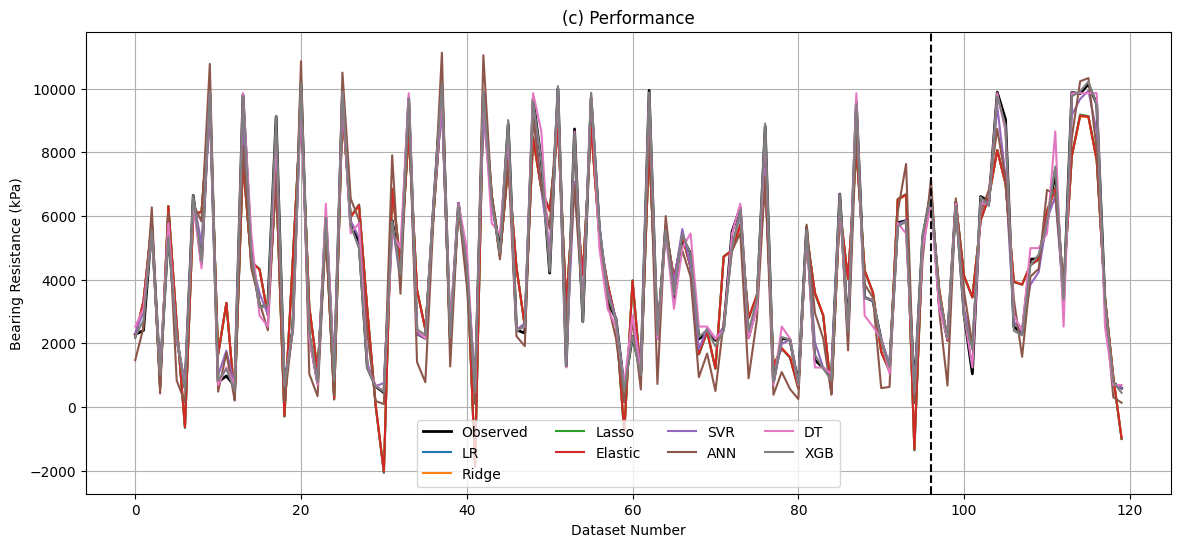

In [ ]:
import numpy as np

# Combine for full visualization
y_all = np.concatenate([y_train, y_test])

pred_lr = np.concatenate([lr.predict(X_train_scaled), lr.predict(X_test_scaled)])
pred_ridge = np.concatenate([ridge.predict(X_train_scaled), ridge.predict(X_test_scaled)])
pred_lasso = np.concatenate([lasso.predict(X_train_scaled), lasso.predict(X_test_scaled)])
pred_elastic = np.concatenate([elastic.predict(X_train_scaled), elastic.predict(X_test_scaled)])
pred_svr = np.concatenate([best_svr.predict(X_train_scaled), best_svr.predict(X_test_scaled)])
pred_ann = np.concatenate([model.predict(X_train_scaled).flatten(), model.predict(X_test_scaled).flatten()])
pred_dt = np.concatenate([dt.predict(X_train), dt.predict(X_test)])
pred_xgb = np.concatenate([xgb.predict(X_train), xgb.predict(X_test)])

plt.figure(figsize=(14,6))

plt.plot(y_all, label="Observed", color="black", linewidth=2)
plt.plot(pred_lr, label="LR")
plt.plot(pred_ridge, label="Ridge")
plt.plot(pred_lasso, label="Lasso")
plt.plot(pred_elastic, label="Elastic")
plt.plot(pred_svr, label="SVR")
plt.plot(pred_ann, label="ANN")
plt.plot(pred_dt, label="DT")
plt.plot(pred_xgb, label="XGB")

# Train-test split line
plt.axvline(len(y_train), linestyle='--', color='black')

plt.title("(c) Performance")
plt.xlabel("Dataset Number")
plt.ylabel("Bearing Resistance (kPa)")

plt.legend(ncol=4)
plt.grid()
plt.show()

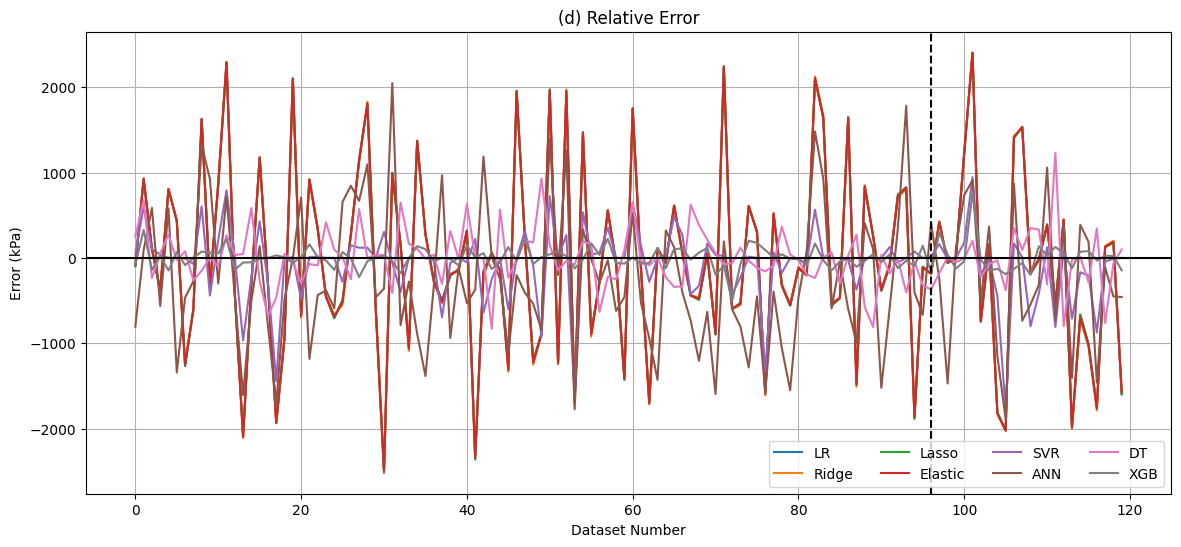

In [ ]:
# Error = predicted - actual
err_lr = pred_lr - y_all
err_ridge = pred_ridge - y_all
err_lasso = pred_lasso - y_all
err_elastic = pred_elastic - y_all
err_svr = pred_svr - y_all
err_ann = pred_ann - y_all
err_dt = pred_dt - y_all
err_xgb = pred_xgb - y_all

plt.figure(figsize=(14,6))

plt.plot(err_lr, label="LR")
plt.plot(err_ridge, label="Ridge")
plt.plot(err_lasso, label="Lasso")
plt.plot(err_elastic, label="Elastic")
plt.plot(err_svr, label="SVR")
plt.plot(err_ann, label="ANN")
plt.plot(err_dt, label="DT")
plt.plot(err_xgb, label="XGB")

plt.axhline(0, color='black')
plt.axvline(len(y_train), linestyle='--', color='black')

plt.title("(d) Relative Error")
plt.xlabel("Dataset Number")
plt.ylabel("Error (kPa)")

plt.legend(ncol=4)
plt.grid()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/tmp/ipykernel_25370/2826197830.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(train_data, labels=labels, patch_artist=True)


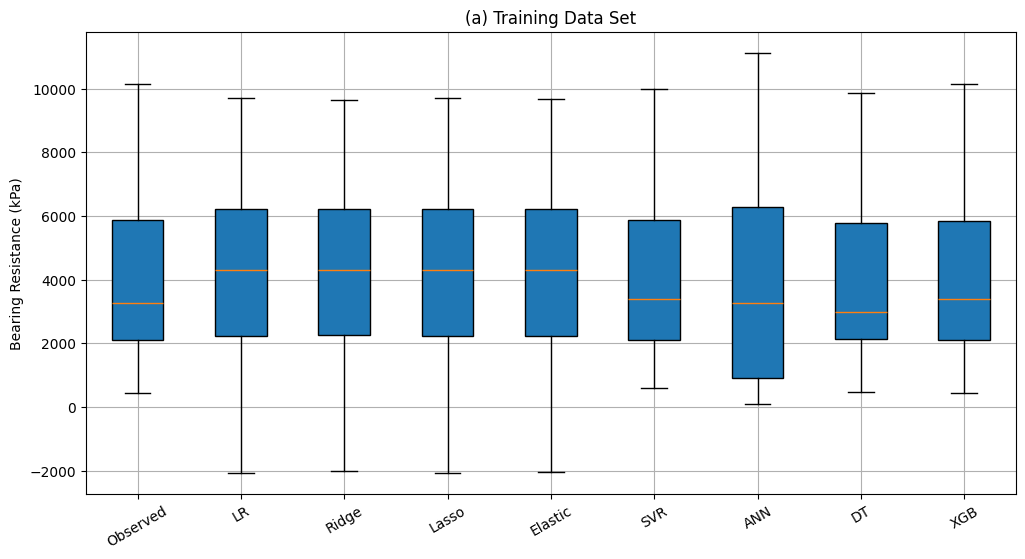

In [ ]:
import matplotlib.pyplot as plt

# --- Predictions (Training) ---
train_data = [
    y_train,
    lr.predict(X_train_scaled),
    ridge.predict(X_train_scaled),
    lasso.predict(X_train_scaled),
    elastic.predict(X_train_scaled),
    best_svr.predict(X_train_scaled),
    model.predict(X_train_scaled).flatten(),
    dt.predict(X_train),
    xgb.predict(X_train)
]

labels = [
    "Observed",
    "LR",
    "Ridge",
    "Lasso",
    "Elastic",
    "SVR",
    "ANN",
    "DT",
    "XGB"
]

plt.figure(figsize=(12,6))

plt.boxplot(train_data, labels=labels, patch_artist=True)

plt.title("(a) Training Data Set")
plt.ylabel("Bearing Resistance (kPa)")
plt.grid(True)

plt.xticks(rotation=30)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


/tmp/ipykernel_25370/2973365576.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(test_data, labels=labels, patch_artist=True)


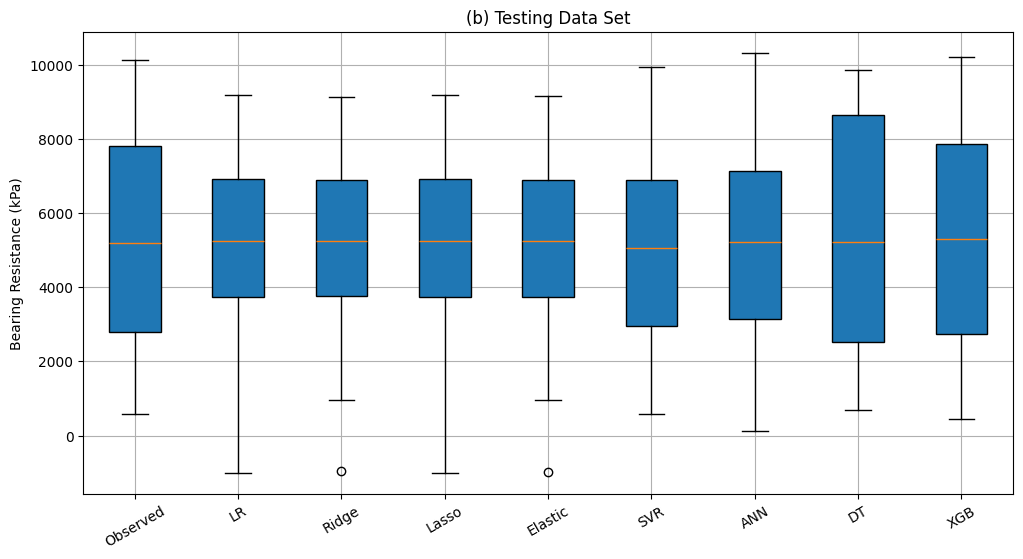

In [ ]:
# --- Predictions (Testing) ---
test_data = [
    y_test,
    lr.predict(X_test_scaled),
    ridge.predict(X_test_scaled),
    lasso.predict(X_test_scaled),
    elastic.predict(X_test_scaled),
    best_svr.predict(X_test_scaled),
    model.predict(X_test_scaled).flatten(),
    dt.predict(X_test),
    xgb.predict(X_test)
]

plt.figure(figsize=(12,6))

plt.boxplot(test_data, labels=labels, patch_artist=True)

plt.title("(b) Testing Data Set")
plt.ylabel("Bearing Resistance (kPa)")
plt.grid(True)

plt.xticks(rotation=30)
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


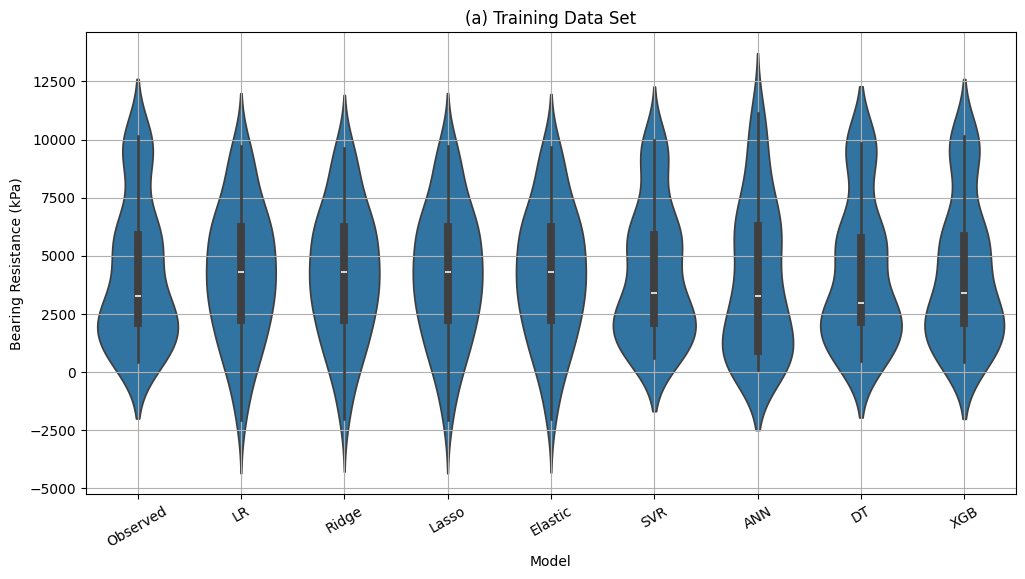

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Training Predictions ---
train_dict = {
    "Observed": y_train,
    "LR": lr.predict(X_train_scaled),
    "Ridge": ridge.predict(X_train_scaled),
    "Lasso": lasso.predict(X_train_scaled),
    "Elastic": elastic.predict(X_train_scaled),
    "SVR": best_svr.predict(X_train_scaled),
    "ANN": model.predict(X_train_scaled).flatten(),
    "DT": dt.predict(X_train),
    "XGB": xgb.predict(X_train)
}

# Convert to DataFrame
train_df = pd.DataFrame(train_dict)

# Melt for seaborn
train_melt = train_df.melt(var_name="Model", value_name="Bearing Resistance")

# Plot
plt.figure(figsize=(12,6))
sns.violinplot(x="Model", y="Bearing Resistance", data=train_melt)

plt.title("(a) Training Data Set")
plt.ylabel("Bearing Resistance (kPa)")
plt.xticks(rotation=30)
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


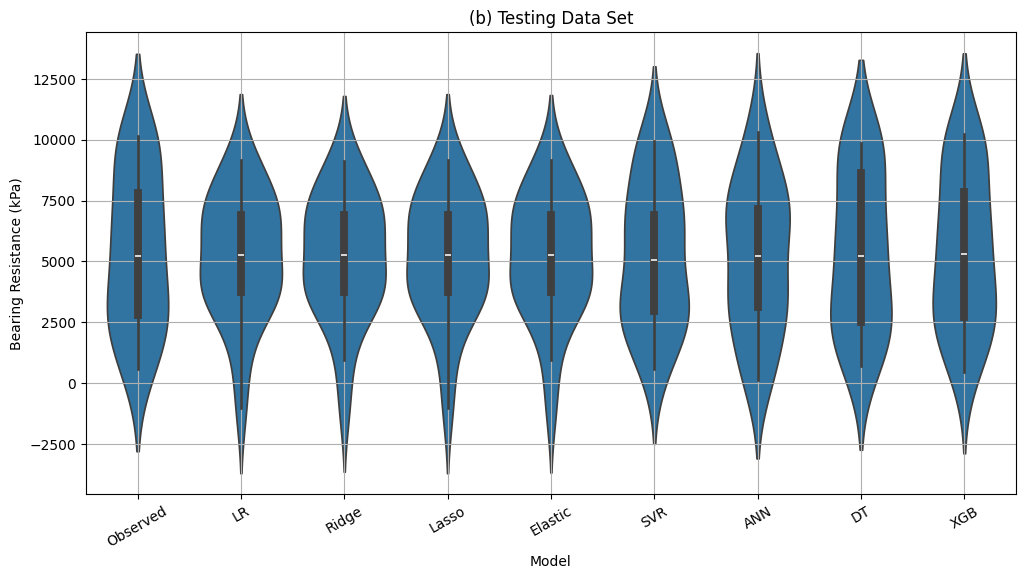

In [ ]:
# --- Testing Predictions ---
test_dict = {
    "Observed": y_test,
    "LR": lr.predict(X_test_scaled),
    "Ridge": ridge.predict(X_test_scaled),
    "Lasso": lasso.predict(X_test_scaled),
    "Elastic": elastic.predict(X_test_scaled),
    "SVR": best_svr.predict(X_test_scaled),
    "ANN": model.predict(X_test_scaled).flatten(),
    "DT": dt.predict(X_test),
    "XGB": xgb.predict(X_test)
}

# Convert to DataFrame
test_df = pd.DataFrame(test_dict)

# Melt
test_melt = test_df.melt(var_name="Model", value_name="Bearing Resistance")

# Plot
plt.figure(figsize=(12,6))
sns.violinplot(x="Model", y="Bearing Resistance", data=test_melt)

plt.title("(b) Testing Data Set")
plt.ylabel("Bearing Resistance (kPa)")
plt.xticks(rotation=30)
plt.grid(True)

plt.show()

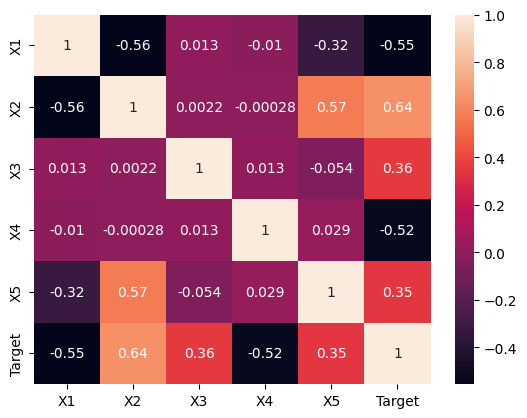

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
pip install skillmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00


PIPELINE

In [ ]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import pickle

# Preprocessing (scaling inside pipeline)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['X1','X2','X3','X4','X5'])
])

# Final pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

# IMPORTANT: use RAW X_train (not scaled)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

In [ ]:
pickle.dump(pipeline, open("pipeline.pkl", "wb"))

In [ ]:
pipeline = pickle.load(open("pipeline.pkl", "rb"))

def predict_input(input_dict):
    import pandas as pd

    df = pd.DataFrame([input_dict])

    # Ensure correct column order
    df = df[['X1','X2','X3','X4','X5']]

    return pipeline.predict(df)

In [ ]:
print(predict_input({"X1":1,"X2":9,"X3":50,"X4":20,"X5":5}))
print(predict_input({"X1":1,"X2":18,"X3":50,"X4":20,"X5":5}))
print(predict_input({"X1":1,"X2":50,"X3":100,"X4":45,"X5":5}))

[4887.9956]
[8880.511]
[6411.8765]


In [ ]:
from google.colab import files
files.download("pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.8.0


In [ ]:
import pandas as pd

df = pd.read_excel("AP data.xlsx")

for col in ['X2', 'X3', 'X4', 'X5']:
    print(f"{col} → min: {df[col].min()}, max: {df[col].max()}")

X2 → min: 0.243183973847165, max: 1084.27222499366
X3 → min: 0.161001464033106, max: 717.849177611207
X4 → min: 0.111786096765939, max: 498.415080345455
X5 → min: 0.0303550125598854, max: 135.342376750133
